In [1]:
import pickle
from matplotlib import pyplot as plt
from matplotlib import colors

from matplotlib.axes import Axes
import numpy as np
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator, FixedLocator, NullLocator)
from collections import Counter

from hubo_qaoa.utils.graph_to_hubo_hamiltonian import graph_to_hubo_hamiltonian
from hubo_qaoa.utils.gfa_utils import gfa_file_to_graph
from qiskit_qaoa.utils.string_utils import evaluate_sparse_pauli_samples

In [2]:
data_file = '/lustre/scratch127/qpg/jc59/new_hubo_formulation/circuit_depths/results.couplingall.precompute.0.pkl'
with open(data_file, 'rb') as f:
    res = pickle.load(f)
list(res.keys())

['test_N2_W2',
 'trivial',
 'test_N3_W4',
 'test_N4_W5',
 'test_N7_W2',
 'test_N7_W3',
 'test_N7_W4',
 'test_N8_W2',
 'test_N8_W3',
 'test_N8_W5',
 'test_N8_W6']

In [3]:
data_file = '/lustre/scratch127/qpg/jc59/new_hubo_formulation/circuit_depths/results.couplinggrid.precompute.120.pkl'
with open(data_file, 'rb') as f:
    res = pickle.load(f)
list(res.keys())

['test_N2_W2',
 'trivial',
 'test_N3_W4',
 'test_N4_W5',
 'test_N7_W2',
 'test_N7_W3',
 'test_N7_W4',
 'test_N8_W2',
 'test_N8_W3']

In [4]:
res['test_N7_W4']['rzz']['circuit'].count_ops()

OrderedDict([('cx', 1339), ('rzz', 510), ('rz', 207), ('swap', 107)])

In [ ]:
def plot_dist(
    axs: list[Axes], 
    filename, copy_numbers, maxdb, maxdg, shots,
    p = 6, db = 0.1, dg = 4.0,
    normalise=True
) -> list[Axes]:
    filepath = f'/nfs/users/nfs_j/jc59/quantumwork/pangenome/data/{filename}.gfa'
    graph, n, V, T = gfa_file_to_graph(filepath, copy_numbers)
    hamiltonian, norm = graph_to_hubo_hamiltonian(graph, n, T, lamda=10, constraint_terms=1.0)
    with open(f'/lustre/scratch127/qpg/jc59/new_hubo_formulation/nonvariational/nonvariational.{filename}.db{maxdb}.dg{maxdg}.shots{shots}.pkl', 'rb') as f:
        res = pickle.load(f)
    with open(f'/lustre/scratch127/qpg/jc59/new_hubo_formulation/nonvariational/nonvariational.{filename}.db{maxdb}.dg{maxdg}.ps{p}.shots{shots}.betaT{beta_T}.eps{eps}.alpha{alpha}.pkl', 'rb') as f:
        res = pickle.load(f)
        
    
    samples_dict: dict[tuple, str] = res['samples_dict']
    energies = res['energies']
    delta_b_fixed = res['delta_b_fixed'] 
    delta_g_fixed = res['delta_g_fixed']
    iters = ['0', '5', '9']
    energies = np.array(energies)
    if normalise:
        energies /= energies.max()
        # energies /= energies[0,0]
    
    
    keys = samples_dict.keys()
    true_key = None
    for key in keys:
        if key[0] == p and np.abs(key[1] * db - delta_b_fixed)**2 < 0.0005 and np.abs(key[1] * dg - delta_g_fixed)**2 < 0.0005:
            true_key = key
            break
    if true_key is None:
        raise Exception('Could not find key')
    print(filename, true_key)

    cutoff=25
    ax = axs[0]
    random_samples = np.random.choice(('0', '1'), (shots, n*T))
    rand_samples = [''.join(sample) for sample in random_samples]
    rand_vals = np.round(norm * (evaluate_sparse_pauli_samples(rand_samples, hamiltonian)), 2)
    ax.hist(rand_vals, bins=range(cutoff+1), weights=[1/shots]*len(rand_vals), rwidth=1, log=True)
    ax.set_xlim(0, cutoff)
    ax.set_ylim(10**-3, 10**0)

    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(AutoMinorLocator(10))
    ax.text(.95, .99, 'Iter = -1', ha='right', va='top', transform=ax.transAxes)
    
    for i in range(1, len(axs)):
        ax = axs[i]
        counter = Counter(samples_dict[true_key][i-1])
        
        evals = np.round(norm * (evaluate_sparse_pauli_samples(list(counter.keys()), hamiltonian)), 2)
        energies = [count * [evals[idx]] for idx, count in enumerate(counter.values()) if evals[idx] < cutoff]
        sample_vals = np.array([x for xs in energies for x in xs])
        print([count for idx, count in enumerate(counter.values()) if evals[idx] < 1e-5])
        print(np.mean(sample_vals))

        ax.hist(sample_vals, bins=range(cutoff+1), weights=[1/shots]*len(sample_vals), rwidth=1, log=True)
        ax.set_xlim(0, cutoff)
        ax.set_ylim(10**-3, 10**0)

        ax.xaxis.set_major_locator(MultipleLocator(10))
        ax.xaxis.set_minor_locator(AutoMinorLocator(10))
        ax.tick_params(axis='x', which='major', length=6)
        ax.tick_params(axis='x', which='minor', length=2)
        ax.text(.95, .99, f'Iter = {iters[i-1]}', ha='right', va='top', transform=ax.transAxes)

    return axs

In [7]:
def plot_several_p_dist(
    axs: list[Axes], 
    filename, copy_numbers, prob,
    db_fixed, dg_fixed, shots,
    ps, rescale,
    max_beta_T=None, eps=None, alpha=None,
    iters=None
) -> list[Axes]:
    filepath = f'/nfs/users/nfs_j/jc59/quantumwork/pangenome/data/{filename}.gfa'
    graph, n, V, T = gfa_file_to_graph(filepath, copy_numbers)
    hamiltonian, norm = graph_to_hubo_hamiltonian(graph, n, T, lamda=10, constraint_terms=1.0)
    hamiltonian = hamiltonian * norm
    num_qubits: int = hamiltonian.num_qubits
    base_file_name = f'/lustre/scratch127/qpg/jc59/new_hubo_formulation/nonvariational/nonvariational.{filename}.db{db_fixed}.dg{dg_fixed}.ps{ps[-1]}.shots{shots}'
    append_str = (f'.betaT{max_beta_T}' if max_beta_T is not None else '') + (f'.eps{eps}' if eps is not None else '') + (f'.alpha{alpha}' if alpha is not None else '')
    with open(f'{base_file_name}{append_str}.pkl', 'rb') as f:
        res = pickle.load(f)
        
    sample_sequence = []
    samples_dict: dict[tuple[int, float], list[list[str]]] = res['samples_dict']
    keys = samples_dict.keys()
    energies = res['energies']
    if iters is None:
        iters = [0, 5, 9]
    energies = np.array(energies)
    
    cutoff=25
    ax = axs[0]
    rand_shots = min(shots*10, 40000)
    random_samples = np.random.choice(('0', '1'), (rand_shots, num_qubits), p=(1-prob,prob))
    rand_samples = [''.join(sample) for sample in random_samples]
    rand_vals = np.round(evaluate_sparse_pauli_samples(rand_samples, hamiltonian), 2)
    ax.hist(rand_vals, bins=range(cutoff+1), weights=[1/rand_shots]*len(rand_vals), rwidth=1, log=True, color='gray')
    ax.set_xlim(0, cutoff)
    ax.set_ylim(1/shots, 10**0)

    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(AutoMinorLocator(10))
    ax.text(.95, .99, 'Iter = 0', ha='right', va='top', transform=ax.transAxes)
    
    for i in range(1, len(axs)):
        ax = axs[i]
        sample_sequence = []
        for p in ps:
            rescale_value = None
            for key in keys:
                if key[0] == p and np.abs(key[1] - rescale)**2 < 0.0005:
                    rescale_value = key[1]
                    break
            if rescale_value is None:
                raise Exception('Could not rescale value')
            if len(samples_dict[(p, rescale_value)]) > 3:
                counter = Counter(samples_dict[(p, rescale_value)][iters[i-1]])
            else:
                counter = Counter(samples_dict[(p, rescale_value)][i-1])
            if i == len(axs) - 1:
                print(p, counter.most_common(2))
            evals = np.round(evaluate_sparse_pauli_samples(list(counter.keys()), hamiltonian), 2)
            
            energies = [count * [evals[idx]] for idx, count in enumerate(counter.values()) if evals[idx] < cutoff]
            sample_vals = np.array([x for xs in energies for x in xs])
            sample_sequence.append(sample_vals)

        ax.hist(sample_sequence, bins=range(cutoff+1), weights=[[1/shots]*len(sample_vals) for sample_vals in sample_sequence], rwidth=1, log=True, label=ps)
        ax.set_xlim(0, cutoff)
        ax.set_ylim(1/shots, 10**0)

        ax.xaxis.set_major_locator(MultipleLocator(10))
        ax.xaxis.set_minor_locator(AutoMinorLocator(10))
        ax.tick_params(axis='x', which='major', length=6)
        ax.tick_params(axis='x', which='minor', length=2)
        ax.text(.95, .99, f'Iter = {iters[i-1] + 1}', ha='right', va='top', transform=ax.transAxes)
          
    ax.legend(loc='best', bbox_to_anchor=(0.8, 0.6, 0.2, 0.4))
    return axs

Keeping constraints at times: [0]
1 [('0001', 1499), ('1110', 509)]
3 [('1110', 3276), ('0001', 110)]
5 [('0001', 3743), ('1110', 57)]
Keeping constraints at times: [1 0]
1 [('000010001', 1462), ('000010100', 151)]
3 [('101110100', 2703), ('101100100', 146)]
5 [('000010001', 1356), ('101110100', 662)]
Keeping constraints at times: [0 2 1]
1 [('000010101000', 1351), ('000000101000', 109)]
3 [('000010101000', 1036), ('000010100001', 265)]
5 [('100001110100', 2559), ('100001100100', 100)]
Keeping constraints at times: [1 0 3 2]
1 [('111100001110100', 733), ('110100001110100', 268)]
3 [('101000010101000', 1765), ('101001010101000', 232)]
5 [('000010101000011', 2232), ('000010101010011', 149)]
Keeping constraints at times: [0 1 3 2]
1 [('111111011110101011001000', 95), ('101111011110101011001000', 77)]
3 [('010111111110101011001000', 294), ('000111111110101011001000', 277)]
5 [('000100000100001001100111', 622), ('100100000100001001100111', 460)]
Keeping constraints at times: [4 1 0 3 2]
1 [

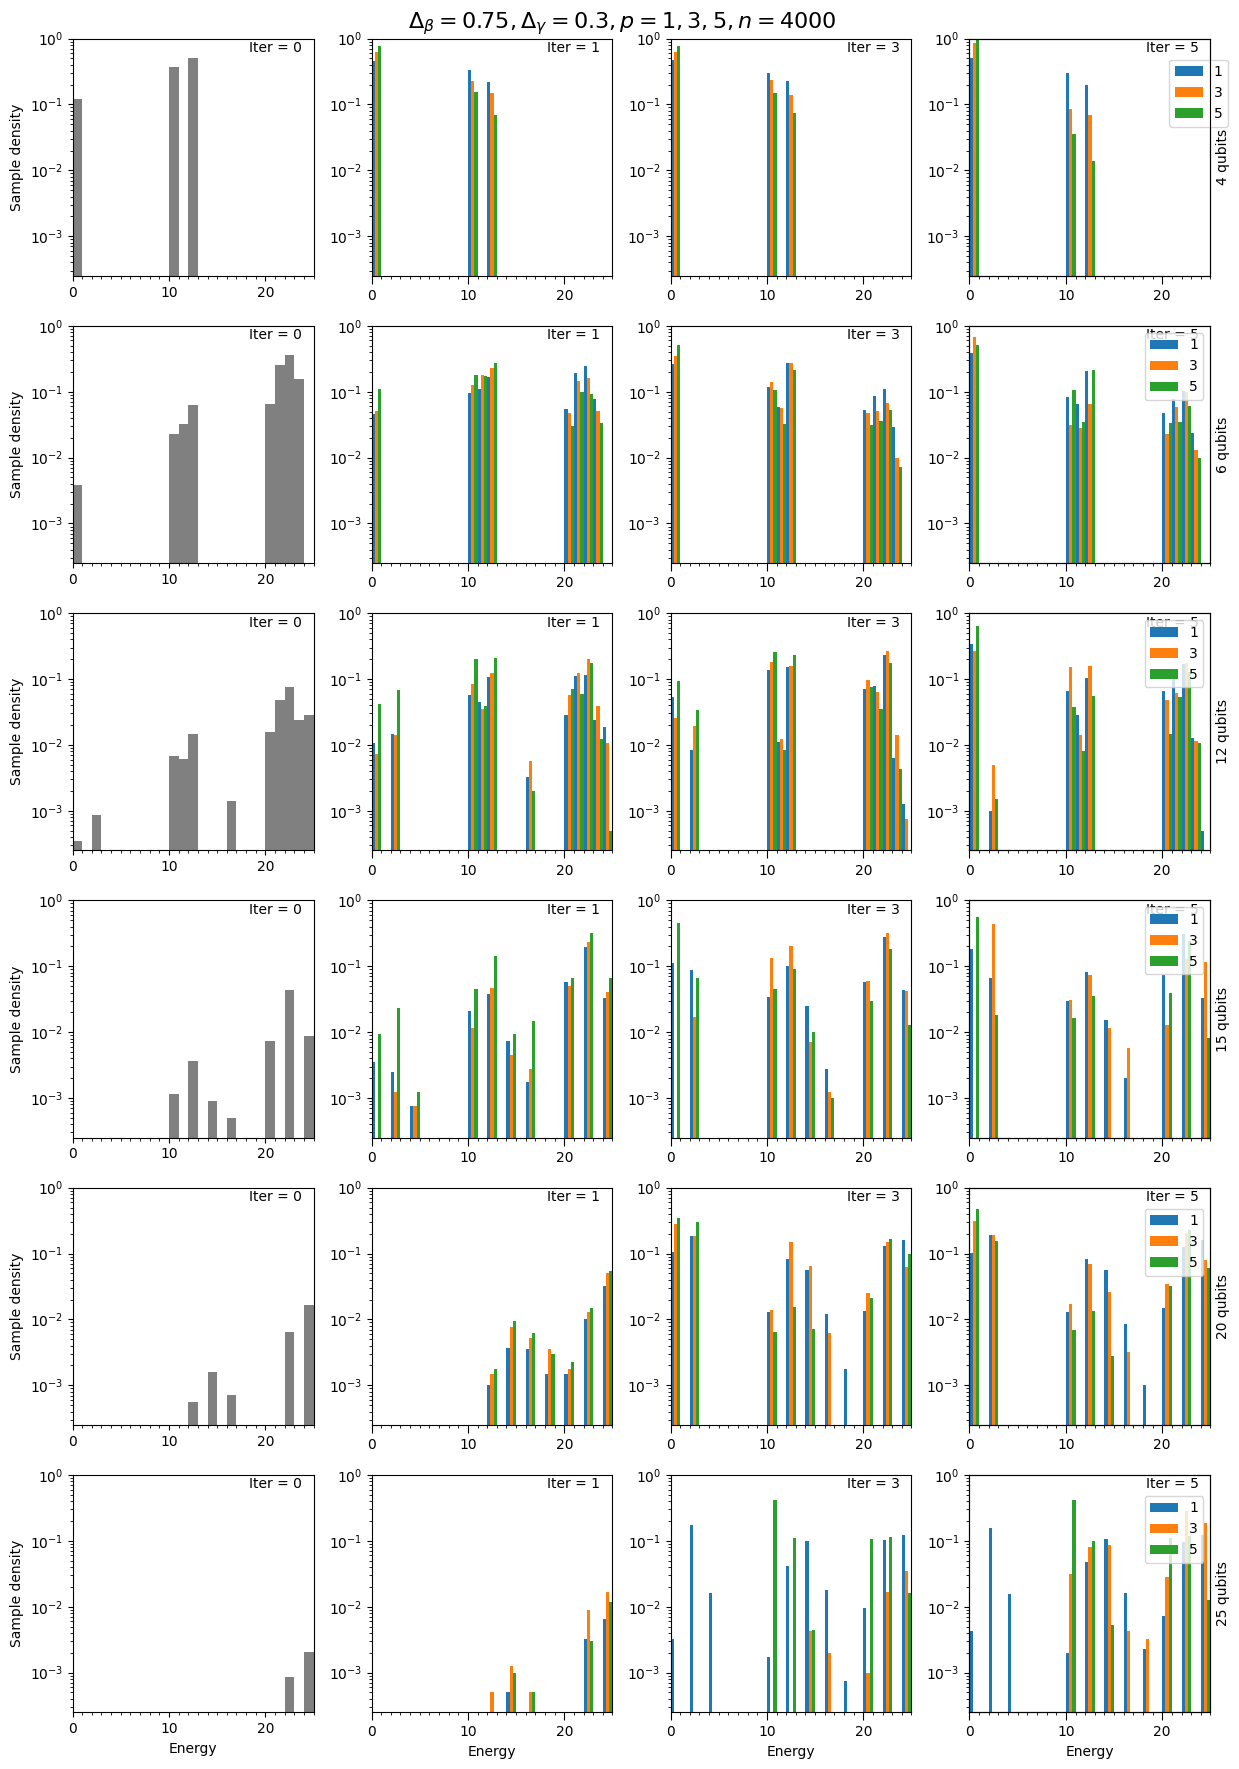

In [ ]:
filenames = ['test_N2_W2', 'trivial','test_N3_W4', 'test_N4_W5','test_N8_W5', 'test_N8_W6']
copy_numbers = [[1,1], [1,1,1], [2,1,1],[2,1,1,1], [1,1,1,1,0,0,0,1], [1,1,0,1,1,1,0,1]]
rows = len(filenames)
prob, db, dg, shots, ps, rescale, beta_T, eps, alpha, iters = 1/2, 0.75, 0.3, 4000, [1,3,5], 1, 0.15, 0.15, 1.0, [0,2,4]

fig, axs = plt.subplots(rows, 4, figsize=(2*6.27,3*rows))
for idx, (f, c) in enumerate(zip(filenames, copy_numbers)):
    plot_several_p_dist(axs[idx, :], f, c, prob, db, dg, shots, ps, rescale, beta_T, eps, alpha, iters)

for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
qubits = [4, 6, 12, 15, 20, 24]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {db}, \\Delta_\\gamma = {dg}, p = 1,3,5, n = {shots}$', fontsize=16)
# fig.set_figheight(3 * len(axs[:, 0]))
# fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()


In [2]:
db_fixed, dg_fixed = 0.75, 0.30
rescale = 10**(0.0)

shots = 4000
ps = [1,3,5]
iters=range(0,10,2)
max_beta_T = 0.15
eps=0.15
alpha=1.0
filename='test_N8_W6'
copy_numbers=[1,1,0,1,1,1,0,1]

filepath = f'/nfs/users/nfs_j/jc59/quantumwork/pangenome/data/{filename}.gfa'
graph, n, V, T = gfa_file_to_graph(filepath, copy_numbers)
hamiltonian, norm = graph_to_hubo_hamiltonian(graph, n, T, lamda=10, constraint_terms=1.0)
hamiltonian = hamiltonian * norm
num_qubits: int = hamiltonian.num_qubits

try:
    with open(f'/lustre/scratch127/qpg/jc59/new_hubo_formulation/nonvariational/nonvariational.{filename}.db{db_fixed}.dg{dg_fixed}.shots{shots}.betaT{max_beta_T}.eps{eps}.alpha{alpha}.pkl', 'rb') as f:
        res = pickle.load(f)
except Exception:
    with open(f'/lustre/scratch127/qpg/jc59/new_hubo_formulation/nonvariational/nonvariational.{filename}.db{db_fixed}.dg{dg_fixed}.ps{ps[-1]}.shots{shots}.betaT{max_beta_T}.eps{eps}.alpha{alpha}.pkl', 'rb') as f:
        res = pickle.load(f) 

Keeping constraints at times: [3 1 2 4 0]


Keeping constraints at times: [3 2 1 0]
1 [('000010101000011', 3495), ('000010101010011', 471)]
3 [('000010101000011', 6646), ('000010101010011', 672)]
5 [('000010101000011', 8696), ('000010101010011', 661)]


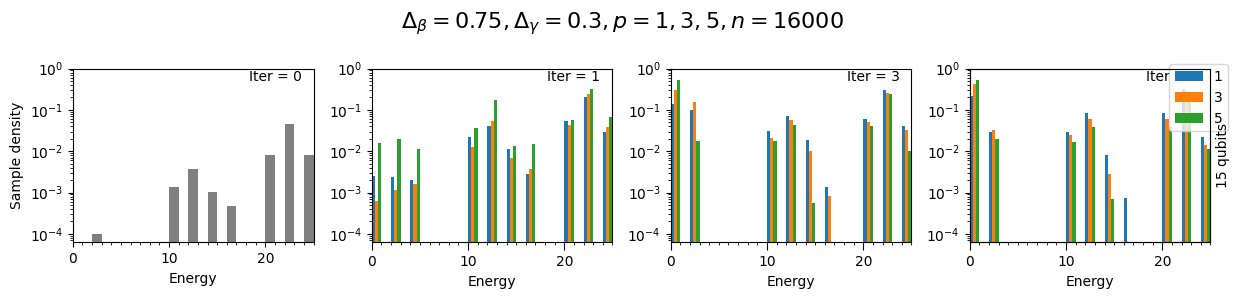

In [17]:
filenames = ['test_N4_W5']
copy_numbers = [[2,1,1,1]]
rows = len(filenames)
prob, db, dg, shots, ps, rescale, beta_T, eps, alpha, iters = 1/2, 0.75, 0.3, 16000, [1,3,5], 1, 0.15, 0.15, 0.05, [0,2,4]

fig, axs = plt.subplots(rows, len(iters)+1, figsize=(2*6.27,3*rows))
axs = np.array(axs).reshape((rows, len(iters)+1))
for idx, (f, c) in enumerate(zip(filenames, copy_numbers)):
    plot_several_p_dist(axs[idx, :], f, c, prob, db, dg, shots, ps, rescale, beta_T, eps, alpha, iters)

for ax in axs[:, 0]:
    ax.set_ylabel(r'Sample density')
    
qubits = [15]
for idx, ax in enumerate(axs[:, -1]):
    twin = ax.twinx()
    twin.set_yticks([])
    twin.set_ylabel(f'{qubits[idx]} qubits')
    
for ax in axs[-1, :]:  
    ax.set_xlabel(r'Energy')  
    
fig.suptitle(f'$\\Delta_\\beta = {db}, \\Delta_\\gamma = {dg}, p = 1,3,5, n = {shots}$', fontsize=16)
# fig.set_figheight(3 * len(axs[:, 0]))
# fig.set_figwidth(3.5 * len(axs[0, :]))
plt.tight_layout()


In [23]:
def get_path(sample):
    nodes = [sample[n*i:n*(i+1)][::-1] for i in range(T)]
    return [list(graph.nodes)[int(node, 2)] for node in nodes]
    

In [32]:
c = Counter(res['samples_dict'][(1,1)][1]).most_common(20)
evals = evaluate_sparse_pauli_samples([x[0] for x in c], hamiltonian)
[(c[i][1], get_path(c[i][0]), evals[i]) for i in range(len(c))]

[(534, ['u7_-', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u0_-'], np.float64(2.0)),
 (139, ['u7_-', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u1_-'], np.float64(2.0)),
 (98, ['u7_+', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u0_-'], np.float64(12.0)),
 (43, ['u6_-', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u0_-'], np.float64(4.0)),
 (38, ['u7_-', 'u5_-', 'u4_-', 'u7_-', 'u2_-', 'u0_-'], np.float64(24.0)),
 (32, ['u7_-', 'u5_-', 'u4_-', 'u3_+', 'u2_-', 'u0_-'], np.float64(22.0)),
 (32, ['u7_-', 'u5_-', 'u0_-', 'u3_-', 'u2_-', 'u0_-'], np.float64(24.0)),
 (31, ['u7_-', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u3_-'], np.float64(14.0)),
 (29, ['u1_-', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u0_-'], np.float64(12.0)),
 (27, ['u5_+', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u0_-'], np.float64(14.0)),
 (26, ['u7_-', 'u5_-', 'u4_-', 'u3_-', 'u0_+', 'u1_-'], np.float64(20.0)),
 (23, ['u7_+', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u1_-'], np.float64(12.0)),
 (23, ['u3_+', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u0_-'], np.float64(14.0)),
 (23, ['u7_-', 'u4_-', 'u4

In [28]:
c = Counter(res['samples_dict'][(1,1)][8]).most_common(20)
evals = evaluate_sparse_pauli_samples([x[0] for x in c], hamiltonian)
[(c[i][1], get_path(c[i][0]), evals[i]) for i in range(len(c))]

[(327, ['u7_-', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u0_-'], np.float64(2.0)),
 (324, ['u7_-', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u1_-'], np.float64(2.0)),
 (69, ['u7_+', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u1_-'], np.float64(12.0)),
 (45, ['u7_-', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u3_-'], np.float64(14.0)),
 (39, ['u7_+', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u0_-'], np.float64(12.0)),
 (30, ['u6_-', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u1_-'], np.float64(4.0)),
 (30, ['u7_-', 'u5_-', 'u4_-', 'u3_-', 'u0_+', 'u1_-'], np.float64(20.0)),
 (28, ['u7_-', 'u5_-', 'u4_+', 'u3_-', 'u2_-', 'u1_-'], np.float64(22.0)),
 (26, ['u6_-', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u0_-'], np.float64(4.0)),
 (26, ['u7_-', 'u5_-', 'u4_-', 'u7_-', 'u2_-', 'u1_-'], np.float64(24.0)),
 (26, ['u7_-', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u6_-'], np.float64(14.0)),
 (25, ['u7_-', 'u4_-', 'u4_-', 'u3_-', 'u2_-', 'u0_-'], np.float64(14.0)),
 (24, ['u5_+', 'u5_-', 'u4_-', 'u3_-', 'u2_-', 'u1_-'], np.float64(14.0)),
 (23, ['u7_-', 'u5_-', 'u4_